# Inteligencia Artificial 2026 — Lab 03

# EJERCICIO 1 — Clasificacion de Digitos

## 1. Dataset y transformaciones (Digits)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# 1) Cargar dataset
digits = load_digits()
X = digits.data              # (1797, 64)
y = digits.target            # (1797,)

# 2) Normalizacion requerida: dividir por 16 (maximo valor de pixel)
X = X / 16.0

# 3) Particion train/test con estratificacion para conservar proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437,), (360,))

## Arquitectura propuesta y justificacion

### Por que una red fully connected aqui?
Las imagenes 8x8 se encuentran aplanadas en un vector de 64 entradas.  
Una red densa puede aprender combinaciones no lineales de estos pixeles para clasificar el digito.

### Arquitectura (al menos 2 capas ocultas)
Se propone:
- Capa oculta 1: **Dense(128, activation='relu')**
- Capa oculta 2: **Dense(64, activation='relu')**
- Capa de salida: **Dense(10, activation='softmax')**

**Justificacion:**
- 128 neuronas permiten aprender una representacion rica desde 64 pixeles.
- 64 neuronas refuerzan la capacidad no lineal sin hacer el modelo excesivo.
- **ReLU** acelera el entrenamiento y evita saturacion.

In [3]:
tf.random.set_seed(42)
np.random.seed(42)

model_cls = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cls.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_cls = model_cls.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3934 - loss: 2.0414 - val_accuracy: 0.8125 - val_loss: 1.2924
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8512 - loss: 1.0122 - val_accuracy: 0.8958 - val_loss: 0.5757
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9116 - loss: 0.4409 - val_accuracy: 0.9236 - val_loss: 0.3499
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9435 - loss: 0.2690 - val_accuracy: 0.9444 - val_loss: 0.2650
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9566 - loss: 0.1936 - val_accuracy: 0.9444 - val_loss: 0.2202
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9698 - loss: 0.1512 - val_accuracy: 0.9514 - val_loss: 0.1958
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9740 - loss: 0.1239 - val_accuracy: 0.9583 - val_loss: 0.1807
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9795 - loss: 0.1044 - val_accuracy: 0.9514 - val_loss:

In [4]:
# Evaluacion en train y test
train_loss, train_acc = model_cls.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model_cls.evaluate(X_test, y_test, verbose=0)

print(f"Train -> loss: {train_loss:.4f}, acc: {train_acc:.4f}")
print(f"Test  -> loss: {test_loss:.4f}, acc: {test_acc:.4f}")

# Predicciones y reporte clasificacion
y_pred_prob = model_cls.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nAccuracy (sklearn):", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Train -> loss: 0.0193, acc: 0.9965
Test  -> loss: 0.0731, acc: 0.9722

Accuracy (sklearn): 0.9722222222222222

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.87      0.94      0.91        36
           2       1.00      1.00      1.00        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      0.86      0.91        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



## Matriz de confusion

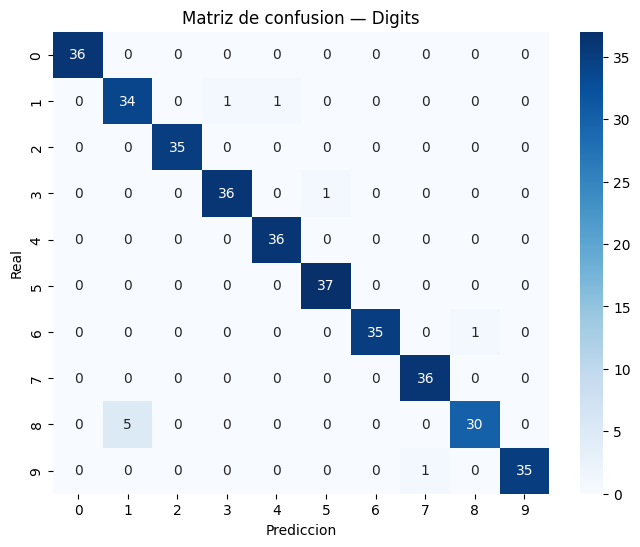

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion — Digits")
plt.show()

## Ejemplos: 5 bien clasificados y 5 mal clasificados

Se muestran ejemplos reconstruyendo la imagen 8x8 desde el vector de 64.
- Bien clasificados: `y_pred == y_test`
- Mal clasificados: `y_pred != y_test`

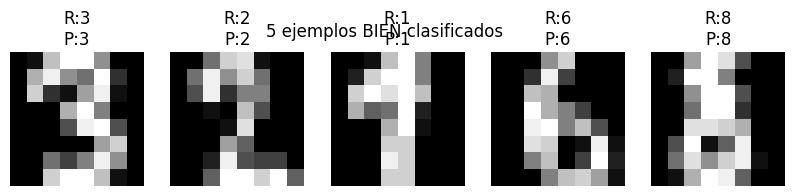

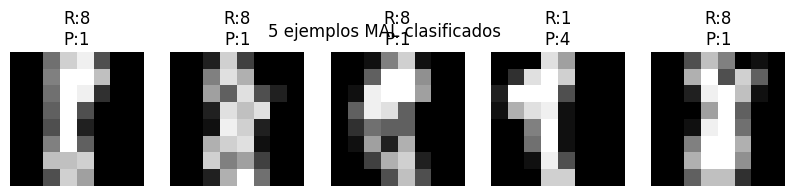

In [6]:
# Indices correctos e incorrectos
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx   = np.where(y_pred != y_test)[0]

# Tomar 5 de cada uno
np.random.shuffle(correct_idx)
np.random.shuffle(wrong_idx)

correct_examples = correct_idx[:5]
wrong_examples = wrong_idx[:5]

def plot_examples(indices, title):
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(indices):
        img = X_test[idx].reshape(8, 8) * 16.0  # regresar a escala original solo para visualizar
        plt.subplot(1, len(indices), i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"R:{y_test[idx]}\nP:{y_pred[idx]}")
    plt.suptitle(title)
    plt.show()

plot_examples(correct_examples, "5 ejemplos BIEN clasificados")
plot_examples(wrong_examples, "5 ejemplos MAL clasificados")

# EJERCICIO 2 — Regresion de Precios (California Housing)

## Dataset y preprocesamiento (California Housing)

**Dataset:** `sklearn.datasets.fetch_california_housing()`  

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

housing = fetch_california_housing()
X2 = housing.data
y2 = housing.target  # continuo

# Split train/test
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Escalamiento obligatorio
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)  # fit SOLO en train
X2_test_scaled  = scaler.transform(X2_test)

X2_train_scaled.shape, X2_test_scaled.shape

((16512, 8), (4128, 8))

## 2. Arquitectura para regresion y justificacion

Se propone una red mas profunda (ejemplo sugerido: 64, 32, 16) debido a la complejidad de las relaciones socioeconomicas:

- Dense(64, relu)
- Dense(32, relu)
- Dense(16, relu)
- Salida: Dense(1, linear)

**Justificacion:**
- ReLU en capas ocultas para no linealidad y entrenamiento estable.
- Salida **lineal** porque en regresion se predice un valor real continuo (no probabilidades).

In [8]:
tf.random.set_seed(42)
np.random.seed(42)

model_reg = keras.Sequential([
    layers.Input(shape=(X2_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear")
])

model_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

early_stop_reg = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_reg = model_reg.fit(
    X2_train_scaled, y2_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=1
)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6977 - mae: 0.9192 - val_loss: 0.4636 - val_mae: 0.4747
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4089 - mae: 0.4566 - val_loss: 0.4120 - val_mae: 0.4502
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3672 - mae: 0.4310 - val_loss: 0.3954 - val_mae: 0.4381
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3492 - mae: 0.4192 - val_loss: 0.3857 - val_mae: 0.4299
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3357 - mae: 0.4099 - val_loss: 0.3689 - val_mae: 0.4188
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3228 - mae: 0.3999 - val_loss: 0.3609 - val_mae: 0.4103
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3128 - mae: 0.3917 - val_loss: 0.3499 - val_mae: 0.4028
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3043 - mae: 0.3850 - val_loss: 0.3450 - val_mae: 0.3974
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

In [9]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

# Predicciones
y2_train_pred = model_reg.predict(X2_train_scaled, verbose=0).ravel()
y2_test_pred  = model_reg.predict(X2_test_scaled,  verbose=0).ravel()

mse_tr, rmse_tr, mae_tr, r2_tr = regression_metrics(y2_train, y2_train_pred)
mse_te, rmse_te, mae_te, r2_te = regression_metrics(y2_test,  y2_test_pred)

print("TRAIN metrics:")
print(f"  MSE:  {mse_tr:.4f}")
print(f"  RMSE: {rmse_tr:.4f}")
print(f"  MAE:  {mae_tr:.4f}")
print(f"  R2:   {r2_tr:.4f}")

print("\nTEST metrics:")
print(f"  MSE:  {mse_te:.4f}")
print(f"  RMSE: {rmse_te:.4f}")
print(f"  MAE:  {mae_te:.4f}")
print(f"  R2:   {r2_te:.4f}")

TRAIN metrics:
  MSE:  0.2297
  RMSE: 0.4793
  MAE:  0.3244
  R2:   0.8282

TEST metrics:
  MSE:  0.2903
  RMSE: 0.5388
  MAE:  0.3507
  R2:   0.7785


## 3. Scatter Plot: Predicciones vs Valores Reales

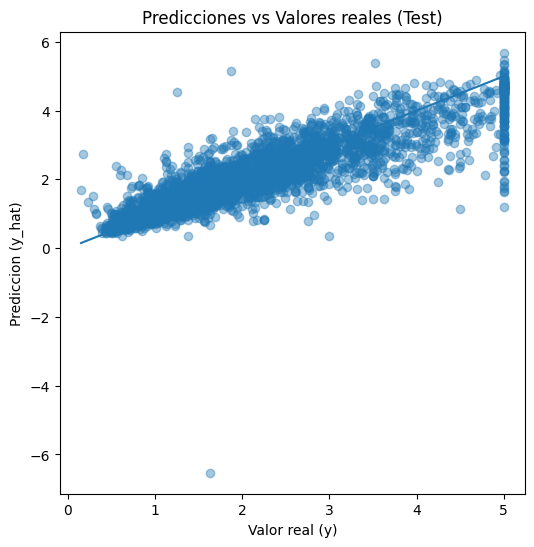

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y2_test, y2_test_pred, alpha=0.4)
plt.xlabel("Valor real (y)")
plt.ylabel("Prediccion (y_hat)")
plt.title("Predicciones vs Valores reales (Test)")
plt.plot([y2_test.min(), y2_test.max()],
         [y2_test.min(), y2_test.max()])
plt.show()

## 4. Tres predicciones para observaciones nuevas

Proceso:
1) Calcular media y std por feature en train (antes de escalar).
2) Crear 3 vectores con combinaciones (media ± fracciones de std).
3) Escalar con el `scaler` entrenado y predecir con la red.

In [11]:
# Media y std en el espacio original (train sin escalar)
mu = X2_train.mean(axis=0)
sd = X2_train.std(axis=0)

# 3 observaciones nuevas (hipoteticas) en espacio original
new_obs = np.array([
    mu + 0.50 * sd,
    mu - 0.30 * sd,
    mu + np.array([0.20, -0.20, 0.10, 0.00, -0.10, 0.15, 0.00, -0.25]) * sd
])

# Escalar usando scaler ya entrenado
new_obs_scaled = scaler.transform(new_obs)

# Predecir
new_pred = model_reg.predict(new_obs_scaled, verbose=0).ravel()

print("Predicciones para 3 observaciones NUEVAS (hipoteticas):")
for i, p in enumerate(new_pred, start=1):
    print(f"  Obs {i}: y_hat = {p:.4f}")

Predicciones para 3 observaciones NUEVAS (hipoteticas):
  Obs 1: y_hat = 1.1544
  Obs 2: y_hat = 6.1093
  Obs 3: y_hat = 1.0285


## 5. Conclusion (Ejercicio 2)

- El escalamiento con StandardScaler fue crucial porque las variables tienen escalas heterogeneas.
- Una red mas profunda (64-32-16) ayuda a capturar relaciones no lineales en datos socioeconomicos.
- MSE es adecuada para entrenar (penaliza fuertemente errores grandes) y MAE ayuda a interpretar el error promedio.
- Se realizaron 3 predicciones en observaciones nuevas hipoteticas (no pertenecen al dataset).